# Environment Preparation

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Only use GPU 0 for training
os.environ["WANDB_DISABLED"] = "true"     # Disable Weights & Biases logging for cleaner output

In [2]:
import os

current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"[INFO] Current directory: {current_dir}")

# 假设你的输出目录在脚本同级或上级
# # 使用 os.path.join 自动处理不同系统的斜杠问题
# base_dir = os.path.join(current_dir, "..", "outputs") 
# json_path = os.path.join(base_dir, unique_output_dir, f"checkpoint-{max_steps}", "trainer_state.json")

# # 转换为绝对路径确保万无一失
# json_path = os.util.abspath(json_path)

[INFO] Current directory: /home/fcr/LLM Learn/Post-training/fine-tune_Llama-3.3-70B_unsloth


In [3]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments, TextStreamer
from unsloth import is_bfloat16_supported
from utilities import check_environment, plot_lr, plot_training_loss, COLORS, plot_training_val_loss
import time
from datetime import datetime
import json

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/fcr/miniconda3/envs/llama/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


🦥 Unsloth Zoo will now patch everything to make training faster!


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using

In [4]:
check_environment()

----------------------------------------------------------------------
LLM TRAINING ENVIRONMENT DIAGNOSTIC REPORT
----------------------------------------------------------------------
[SYSTEM]
Python Version                : 3.10.20
System RAM                    : 1007.53 GB
Disk Free Space               : 713.67 GB

[GPU HARDWARE]
Device Name                   : NVIDIA RTX 5880 Ada Generation
Total VRAM                    : 47.38 GB
Number of GPUs                : 1
Compute Capability            : 8.9

[CUDA SOFTWARE]
PyTorch CUDA Version          : 12.8
Current VRAM Allocated        : 8.12 MB
Native BF16 Support           : Yes

[CONNECTIVITY]
HF Connection                 : OK
HF Token                      : [WARNING] MISSING (Check environment variables)

[LIBRARIES]
unsloth                       : 2025.11.1
transformers                  : 4.57.2
bitsandbytes                  : 0.49.2
xformers                      : 0.0.35
datasets                      : 4.3.0
trl                 

# Model Loading

## Basic Configuration

In [5]:
# 1. Basic Configurations
max_seq_length = 2048      # Supports RoPE Scaling internally
dtype          = None      # None for auto detection (Float16/BFloat16)
load_in_4bit   = True      # Use 4-bit quantization to reduce VRAM usage

## Load Model and Tokenizer

In [6]:
# 2. Load Model and Tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit", # Start with 3B for practice
    # model_name = "unsloth/Llama-3.3-70B-Instruct-bnb-4bit", # Switch to 70B for actual fine-tuning
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

==((====))==  Unsloth 2025.11.1: Fast Llama patching. Transformers: 4.57.2.
   \\   /|    NVIDIA RTX 5880 Ada Generation. Num GPUs = 1. Max memory: 47.383 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [7]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072, padding_idx=128004)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear4bit(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Ll

# LoRA Adapters

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,               # Rank: controls the number of trainable parameters
    target_modules = [    # The parts of the model we want to fine-tune
        "q_proj", "k_proj", "v_proj", "o_proj", # for attention layers
        "gate_proj", "up_proj", "down_proj",    # for feed-forward layers
    ],
    lora_alpha = 16,      # Scaling factor for LoRA updates
    lora_dropout = 0,     # For performance, recommended to 0
    bias = "none",        # For performance, set to none
    use_gradient_checkpointing = "unsloth", # Extremely important: enabling this can significantly save GPU memory
    random_state = 3407,
    use_rslora = False,   # Rank-stable LoRA,
    loftq_config = None,  # Quantization initialization configuration
)

Unsloth 2025.11.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


# Data Preparation

In [9]:
dataset = load_dataset("yahma/alpaca-cleaned", split="train")

In [10]:
raw_example = dataset[1]

print(raw_example, "\n")
print(f"Example type: {type(raw_example)}", "\n")

for key, value in raw_example.items():
    print(f"{key:<15}: {value}")

{'output': 'The three primary colors are red, blue, and yellow. These colors are called primary because they cannot be created by mixing other colors and all other colors can be made by combining them in various proportions. In the additive color system, used for light, the primary colors are red, green, and blue (RGB).', 'input': '', 'instruction': 'What are the three primary colors?'} 

Example type: <class 'dict'> 

output         : The three primary colors are red, blue, and yellow. These colors are called primary because they cannot be created by mixing other colors and all other colors can be made by combining them in various proportions. In the additive color system, used for light, the primary colors are red, green, and blue (RGB).
input          : 
instruction    : What are the three primary colors?


In [11]:
# Prompt Formatting
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token

In [12]:
def formatting_prompts(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = [alpaca_prompt.format(instruction, input, output) + EOS_TOKEN for instruction, input, output in zip(instructions, inputs, outputs)]
    return {"text": texts}

In [13]:
dataset = dataset.map(formatting_prompts, batched = True)
train_val = dataset.train_test_split(test_size=0.03, seed=3407)
train_dataset = train_val["train"]
eval_dataset = train_val["test"]
print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(eval_dataset)}")

Train dataset size: 50207
Eval dataset size: 1553


In [14]:
print(f"Type: {type(dataset[1])}", "\n")
print(dataset[1]["text"])

Type: <class 'dict'> 

Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
What are the three primary colors?

### Input:


### Response:
The three primary colors are red, blue, and yellow. These colors are called primary because they cannot be created by mixing other colors and all other colors can be made by combining them in various proportions. In the additive color system, used for light, the primary colors are red, green, and blue (RGB).<|eot_id|>


# Training

## Train

In [ ]:
current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
unique_output_dir = f"{current_dir}/outputs_{run_id}"
max_steps = 20

if not os.path.exists(unique_output_dir):
    os.makedirs(unique_output_dir)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2, # Number of CPU cores used for data loading
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 4, # Number of parallel data per GPU
        gradient_accumulation_steps = 8, # Effective batch size = per_device_train_batch_size * gradient_accumulation_steps
        warmup_steps = 5,
        max_steps = max_steps, # Total number of training steps
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(), # Use FP16 if BFloat16 is not supported
        bf16 = is_bfloat16_supported(),
        logging_steps = 1, # Log training loss every 1 step
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear", # or "cosine" etc.
        seed = 3407,
        eval_strategy = "steps",
        # evaluation_strategy="steps", # for older versions of transformers
        eval_steps=20, # Evaluate every 20 steps
        save_strategy="steps",
        save_steps=20, # Save checkpoint every 20 steps
        output_dir = unique_output_dir,
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        greater_is_better=False, # because we want to minimize the loss
        # report_to = "wandb", # Upload the loss curve to the cloud
    ),
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [16]:
trainer_stats = trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,207 | Num Epochs = 1 | Total steps = 20
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,1.030400,1.109515


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [17]:
# Training Metrics
gpu_stats = torch.cuda.get_device_properties(0)
print(f"GPU = {gpu_stats.name}. Max memory = {round(gpu_stats.total_memory / 1024 ** 3, 3)} GB.")
print(f"{round(torch.cuda.max_memory_reserved() / 1024 ** 3, 3)} GB of memory reserved.")

GPU = NVIDIA RTX 5880 Ada Generation. Max memory = 47.383 GB.
5.232 GB of memory reserved.


## Save Model

In [18]:
# Save Model
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/chat_template.jinja',
 'lora_model/tokenizer.json')

# Inference

In [19]:
# Inference
FastLanguageModel.for_inference(model) # Switch to inference mode
# instruction = "Continue the Fibonacci sequence."
# input_content = "1, 1, 2, 3, 5, 8"
instruction = "Describe the structure of an atom."
input_content = ""
prompt = alpaca_prompt.format(instruction, input_content, "")
inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")
print(f"{'='*30} PROMPT {'='*30}")
print(prompt)

# inputs = tokenizer(
#     [
#         alpaca_prompt.format(
#             "Continue the Fibonacci sequence.",
#             "1, 1, 2, 3, 5, 8",
#             "",
#         )
#     ],
#     return_tensors="pt",
# ).to("cuda")


outputs = model.generate(**inputs, max_new_tokens=256, use_cache=True,
                        repetition_penalty=1.2, # Penalize repetition to encourage more diverse outputs
                        temperature=0.7,           # Control randomness in generation (lower is more deterministic)
                        )
decoded_output = tokenizer.batch_decode(outputs)
response = decoded_output[0].split("### Response:")[1]
print(f"{'='*30} RESPONSE {'='*30}")
print(response)


============================== PROMPT ==============================
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Describe the structure of an atom.

### Input:


### Response:

============================== RESPONSE ==============================

An atom consists of three main parts: protons, neutrons, and electrons.
Protons are positively charged particles located in the nucleus (the center) of the atom.
Neutrons have no charge and also reside in the nucleus along with protons.
Electrons orbit around the nucleus at various energy levels or electron shells due to their negative electric charges.
This arrangement creates a stable balance between positive and negative forces within each individual atom, allowing atoms to interact meaningfully with one another through covalent bonds as part of molecules composed of multiple atoms together!<|eot_id|>


In [20]:
# Streaming Inference
text_streamer = TextStreamer(tokenizer)
_ = model.generate(**inputs, streamer=text_streamer, max_new_tokens=256,
                    repetition_penalty=1.2, # Penalize repetition to encourage more diverse outputs
                    temperature=0.7,           # Control randomness in generation (lower is more deterministic)
                    )

<|begin_of_text|>Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Describe the structure of an atom.

### Input:


### Response:
An atom consists of three subatomic particles: protons and neutrons in its nucleus (center), surrounded by electrons orbiting around it. The atomic number determines how many protons are present within the nucleus. Each electron has one negative charge to balance out each positive proton's charge.


The nucleus contains either 0 or more than zero protons due to the presence of neutrons which have no electric charges. Protons reside on the outside surface known as nucleons while electrons occupy their specific orbits called energy levels, also referred to as shells. Atoms can be considered neutral when they contain equal numbers of positively charged protons and negatively charged electrons. This stability makes atoms fundamental units

# Plot

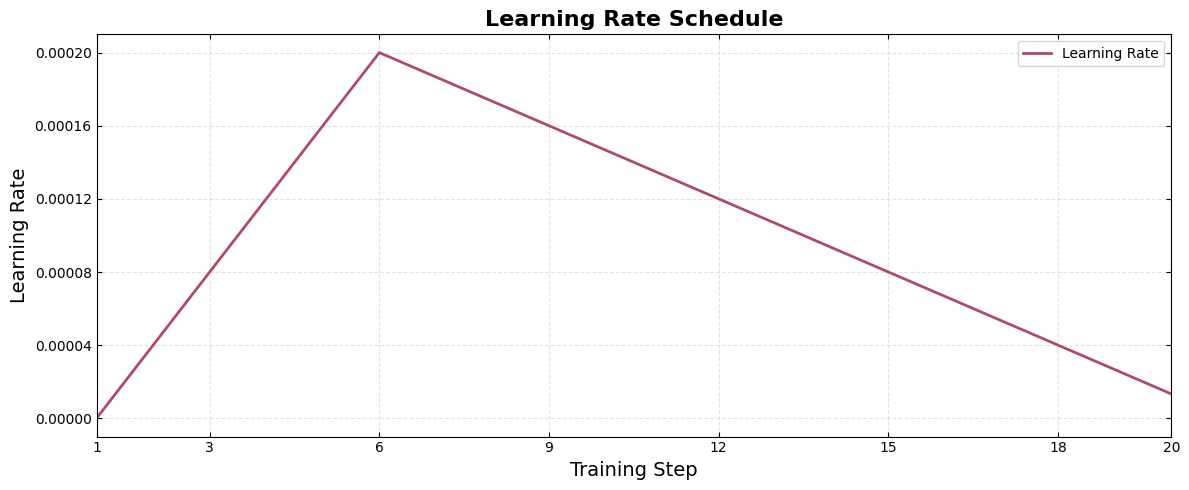

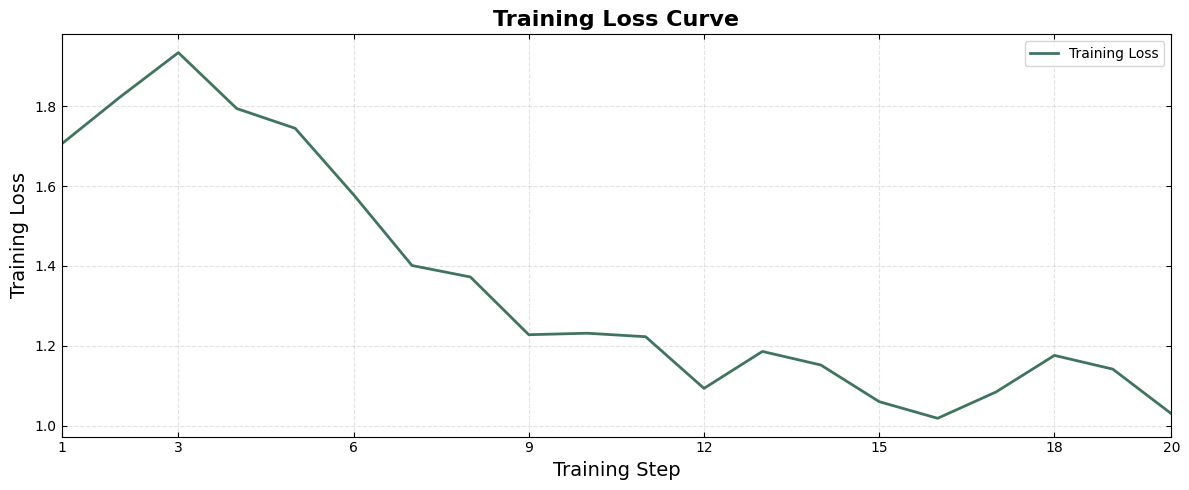

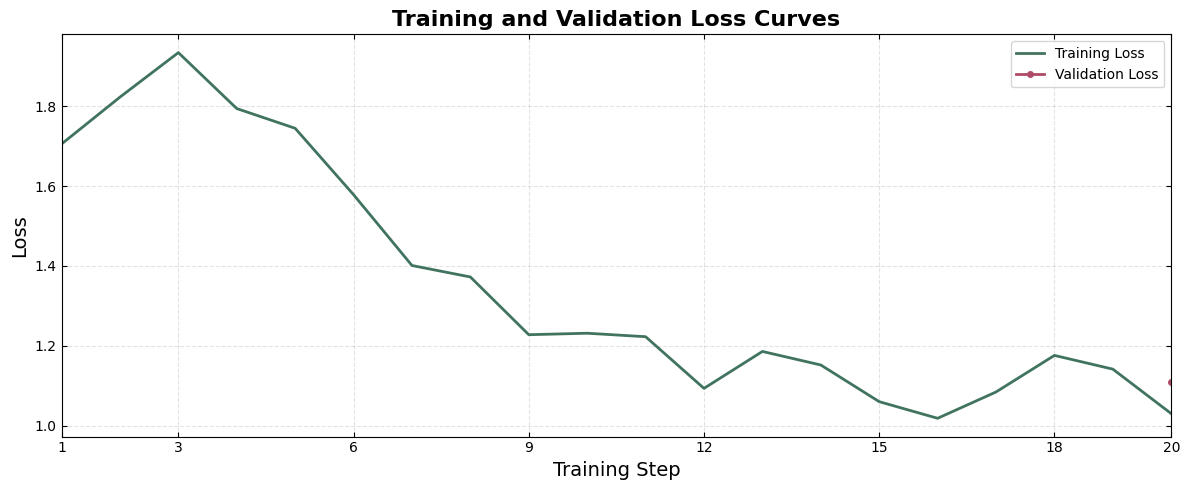

In [22]:
# json_path = f"{unique_output_dir}/checkpoint-200/trainer_state.json"
json_path = f"{unique_output_dir}/checkpoint-{max_steps}/trainer_state.json"

with open(json_path, "r", encoding="utf-8") as f:
    state_data = json.load(f)

history = state_data["log_history"]

train_steps = [entry["step"] for entry in history if "loss" in entry]
train_losses = [entry["loss"] for entry in history if "loss" in entry]

learning_rates = [entry["learning_rate"] for entry in history if "learning_rate" in entry]

eval_steps = [entry["step"] for entry in history if "eval_loss" in entry]
eval_losses = [entry["eval_loss"] for entry in history if "eval_loss" in entry]


COLORS = COLORS()
plot_lr(learning_rates, color=COLORS["purple"], save_path=f"{unique_output_dir}/figures/learning_rate_schedule.pdf")
plot_training_loss(train_losses, train_steps, color=COLORS["green"], save_path=f"{unique_output_dir}/figures/training_loss_curves.pdf")
plot_training_val_loss(train_losses, val_loss_list=eval_losses, train_steps=train_steps, val_steps=eval_steps, train_color=COLORS["green"], val_color=COLORS["purple"], save_path=f"{unique_output_dir}/figures/train_val_loss_curves.pdf")